# PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

In [2]:
#dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/metabolome_dataset.xlsx"
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/metabolome_filtré.xlsx"
#dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_239_paul.xlsx"
#dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_239_saqib.xlsx"
#dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_239.xlsx"



df = pd.read_excel(dataset_total_path)

In [3]:
df['Class'].value_counts()

Class
LP    9
SP    9
LN    9
SN    9
Name: count, dtype: int64

In [4]:
def encodage(df):
    code = {
    'LP' : 1,
    'SP' : 2,
    'LN' : 3,
    'SN' : 4
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


def preprocessing(df):
    df = encodage(df)

    X = df.drop(['Class'], axis = 1)
    y = df['Class']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y



In [5]:
X, y = preprocessing(df)
# Principalement encoder les classes

Class
1    9
2    9
3    9
4    9
Name: count, dtype: int64


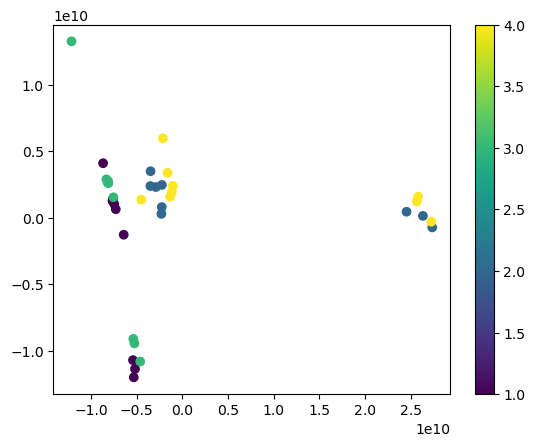

In [6]:
# PCA without pre-processing

model = PCA(n_components=4)
X_reduced = model.fit_transform(X)
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y)
plt.colorbar()

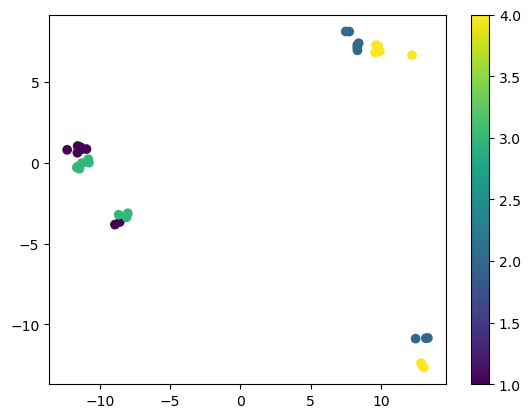

In [7]:
# PCA with pre-processing
# PCA REQUIRES standardization

log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
model = make_pipeline(log2_transformer, StandardScaler(), PCA(n_components=2))
X_reduced = model.fit_transform(X)
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y)
plt.colorbar()

In [8]:
# Get metrics from PCA
pca = model.named_steps['pca'] #Identifier le modèle depuis le pipeline
pca.components_.shape

(2, 239)

In [9]:
#Identifier la var expliquée component par component
print(np.cumsum(pca.explained_variance_ratio_))
print(f'Number of components explaining 99% : {np.argmax(np.cumsum(pca.explained_variance_ratio_) > 0.99)}')

[0.46753172 0.64481828]
Number of components explaining 99% : 0
